# DESARROLLO DE MODELOS DE MACHINE LEARNING

Desarrollado Por: 
* Daniel Arturo Martinez Morales 
* Luis Miguel Ortega Cañate

A continuacion se presenta el desarrollo de la fase de entrenamiento  y test de los modelos  de machine learning  para el desarrollo de un Sistema Clasificador de Resultados de Análisis de Aceite Usado en Motores de Maquinaria Pesada.

**Nota:** Para el desarrollo de esta fase se tiene en cuenta ls fase de exploración de los datos desarrolado previamente en el Noteboock llamado "Exploracion de datos".

## Balanceo de Muestras 

Durante la fase de exploración de datos se identificó un desbalance significativo
en la variable objetivo `Assigned Condition Rating`, donde la clase Normal concentra
la gran mayoría de las observaciones, mientras que las clases Advertencia y Crítico
representan una proporción considerablemente menor del total de muestras.

Este desbalance es inherente al dominio del problema: en operación normal, la mayor
parte de los componentes de una flota minera se encuentran en condición saludable,
y los eventos de advertencia o falla crítica son relativamente poco frecuentes.

Sin embargo, este desbalance introduce
los siguientes riesgos si no es tratado:

- El modelo tiende a clasificar la mayoría de muestras como Normal para maximizar
  el accuracy global, ignorando las clases minoritarias.
- Se genera un sesgo hacia la clase mayoritaria, reduciendo drásticamente el
  desempeño  para las clases Advertencia y Crítico, que son precisamente las
  de mayor valor operativo para el negocio.
- Las métricas globales como el Accuracy resultan engañosas, ocultando el
  bajo desempeño real del modelo sobre las condiciones anómalas.

Detectar una condición Crítica que el modelo clasifica como Normal representa un Falso Negativo de alto costo operativo, asociado directamente a las pérdidas de ~500 kUSD/año documentadas en el planteamiento del problema.


In [5]:
import pandas as pd
data_cleaned = pd.read_excel("../Exploración/Analisis De Aceite Flotas Mineras.xlsx")

In [6]:
print("=== Distribución original de clases ===")
print(data_cleaned['Assigned Condition Rating'].value_counts())
print(data_cleaned['Assigned Condition Rating'].value_counts(normalize=True)
      .mul(100).round(2).astype(str) + ' %')

=== Distribución original de clases ===
Assigned Condition Rating
Normal      3607
Warning      522
Critical     154
Name: count, dtype: int64
Assigned Condition Rating
Normal      84.22 %
Warning     12.19 %
Critical      3.6 %
Name: proportion, dtype: object


In [12]:
import pandas as pd
import numpy as np


# CALIFICACIÓN SACODE - Generación de Límites Condenatorios (Metodología Noria)


## Definición de Predictores según cada Categoría
Salud = data_cleaned[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]

Desgaste = data_cleaned[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]

Contaminacion = data_cleaned[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]



def calcular_limites(df: pd.DataFrame, 
                     factor_warning: float = 2.0, 
                     factor_critico: float = 3.0) -> pd.DataFrame:

    stats = pd.DataFrame({
        'media'           : df.mean(),
        'sigma'           : df.std(),
        'lim_warn_sup'    : df.mean() + factor_warning * df.std(),
        'lim_warn_inf'    : df.mean() - factor_warning * df.std(),
        'lim_critico_sup' : df.mean() + factor_critico * df.std(),
        'lim_critico_inf' : df.mean() - factor_critico * df.std(),
    })

    stats['lim_warn_inf']    = stats['lim_warn_inf'].clip(lower=0)
    stats['lim_critico_inf'] = stats['lim_critico_inf'].clip(lower=0)

    return stats



def clasificar_predictor(valor: float, 
                         lim_warn_sup: float, 
                         lim_critico_sup: float) -> str:

    if valor <= lim_warn_sup:
        return 'Normal'
    elif valor <= lim_critico_sup:
        return 'Advertencia'
    else:
        return 'Crítico'



# Función: Calificación SACODE por categoría (criterio de peor caso)


def calificar_categoria(df: pd.DataFrame, limites: pd.DataFrame) -> pd.Series:

    orden_severidad = {'Normal': 0, 'Advertencia': 1, 'Crítico': 2}
    inv_orden       = {v: k for k, v in orden_severidad.items()}

    calificaciones = pd.DataFrame(index=df.index)

    for col in df.columns:
        lim_w = limites.loc[col, 'lim_warn_sup']
        lim_c = limites.loc[col, 'lim_critico_sup']
        calificaciones[col] = df[col].apply(
            lambda x: clasificar_predictor(x, lim_w, lim_c)
        )

    # Peor caso: máximo nivel de severidad entre todos los predictores por fila
    peor_caso = calificaciones.map(lambda x: orden_severidad[x]).max(axis=1)

    return peor_caso.map(inv_orden)



# Cálculo de Límites por Categoría


limites_salud        = calcular_limites(Salud)
limites_desgaste     = calcular_limites(Desgaste)
limites_contaminacion = calcular_limites(Contaminacion)

print("=== Límites Salud ===")
print(limites_salud.round(3), "\n")

print("=== Límites Desgaste ===")
print(limites_desgaste.round(3), "\n")

print("=== Límites Contaminación ===")
print(limites_contaminacion.round(3), "\n")

# Asignación de Calificación SACODE al dataset


data_cleaned['SACODE_Salud']         = calificar_categoria(Salud,         limites_salud)
data_cleaned['SACODE_Desgaste']      = calificar_categoria(Desgaste,      limites_desgaste)
data_cleaned['SACODE_Contaminacion'] = calificar_categoria(Contaminacion, limites_contaminacion)

=== Límites Salud ===
                              media    sigma  lim_warn_sup  lim_warn_inf  \
Boro (ppm)                   57.419   39.573       136.565         0.000   
Calcio (ppm)               2045.069  690.602      3426.273       663.865   
Cinc (ppm)                 1351.095  149.697      1650.489      1051.702   
Fosforado (ppm)            1179.651   78.502      1336.655      1022.647   
Magnesio (ppm)              241.588  142.551       526.691         0.000   
Molibdeno (ppm)              53.587   14.047        81.680        25.494   
Nitración JOAP (Abs/cm)       5.791    1.364         8.518         3.063   
Oxidación JOAP (Abs/cm)      13.620    2.617        18.855         8.385   
Sulfatación JOAP (Abs/cm)    18.457    2.613        23.683        13.231   
Sodio (ppm)                   5.874   47.363       100.600         0.000   

                           lim_critico_sup  lim_critico_inf  
Boro (ppm)                         176.139            0.000  
Calcio (ppm)     

In [13]:

# Limite Warning sodio
limites_salud.loc['Sodio (ppm)', 'lim_warn_sup'] = 40
# Limite Critico sodio
limites_salud.loc['Sodio (ppm)', 'lim_critico_sup'] = 100
# Limite Warning  Oxidacion JOAP
limites_salud.loc['Oxidación JOAP (Abs/cm)', 'lim_warn_sup'] = 19
# Limite Critico  Oxidacion JOAP
limites_salud.loc['Oxidación JOAP (Abs/cm)', 'lim_critico_sup'] = 21
# Limite Warning Cobre
limites_desgaste.loc['Cobre (ppm)', 'lim_warn_sup'] = 6
# Limite Critico Cobre
limites_desgaste.loc['Cobre (ppm)', 'lim_critico_sup'] = 8
#Limite Warning Plomo
limites_desgaste.loc['Plomo (ppm)', 'lim_warn_sup'] = 4
#Limite Critico Plomo
limites_desgaste.loc['Plomo (ppm)', 'lim_critico_sup'] = 6

In [15]:
data_cleaned['SACODE_Salud']         = calificar_categoria(Salud,         limites_salud)
data_cleaned['SACODE_Desgaste']      = calificar_categoria(Desgaste,      limites_desgaste)
data_cleaned['SACODE_Contaminacion'] = calificar_categoria(Contaminacion, limites_contaminacion)

In [16]:
data_cleaned['SACODE_General'] = data_cleaned[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

### Estrategia de Balanceo

Para mitigar el desbalance se aplica la técnica SMOTE, que genera muestras sintéticas
para las clases minoritarias interpolando entre observaciones reales del espacio
de características, en lugar de simplemente duplicar registros existentes.

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


# Variables predictoras y variable objetivo
X = data_cleaned.drop(columns=['Assigned Condition Rating',
                                'ACR_Homologado',
                                'Fault Effect',
                                'SACODE_Salud',
                                'SACODE_Desgaste',
                                'SACODE_Contaminacion',
                                'SACODE_General','Flota','Rule Based Rating'])

y = data_cleaned['Assigned Condition Rating']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       
)

print("=== Distribución antes de SMOTE (Train) ===")
print(y_train.value_counts())

# Aplicación de SMOTE exclusivamente sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n=== Distribución después de SMOTE (Train) ===")
print(pd.Series(y_train_bal).value_counts())
print("\n=== Conjunto de prueba (sin modificar) ===")
print(y_test.value_counts())

=== Distribución antes de SMOTE (Train) ===
Assigned Condition Rating
Normal      2885
Warning      418
Critical     123
Name: count, dtype: int64

=== Distribución después de SMOTE (Train) ===
Assigned Condition Rating
Normal      2885
Warning     2885
Critical    2885
Name: count, dtype: int64

=== Conjunto de prueba (sin modificar) ===
Assigned Condition Rating
Normal      722
Warning     104
Critical     31
Name: count, dtype: int64


c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Daniel Martinez\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Daniel Martinez\AppData\Local\Pro

## Parte V: Calificación SACODE (Salud - Contaminación - Desgaste)

* En esta etapa se incluyen nuevas features al dataset previamente depurado.
* Se agregan 3 nuevas variables al dataframe: **Salud**, **Contaminación** y **Desgaste**.
* Cada una de estas variables puede tomar 3 estados posibles: **Normal**, **Advertencia** y **Crítico**.
* La calificación se construye mediante la generación de **límites condenatorios** para los predictores
  asociados a cada categoría SACODE, siguiendo la metodología de Noria.
* Los límites se calculan a partir de la media y la desviación estándar de cada predictor,
  definidos de la siguiente manera:

  * **Límite Warning:**
    $$L_{warning} = \bar{x} \pm 2\sigma$$

  * **Límite Crítico:**
    $$L_{critico} = \bar{x} \pm 3\sigma$$

* La lógica de clasificación por predictor opera de la siguiente forma:
  * Si el valor observado se encuentra dentro del **Límite Warning** → estado **Normal**
  * Si el valor observado supera el **Límite Warning** pero no el **Límite Crítico** → estado **Advertencia**
  * Si el valor observado supera el **Límite Crítico** → estado **Crítico**

* La calificación final de cada categoría SACODE (Salud, Contaminación, Desgaste)
  corresponde al estado más severo registrado entre todos sus predictores asociados
  (criterio de peor caso).

In [35]:
Salud_train = X_train_bal[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]

Desgaste_train = X_train_bal[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]

Contaminacion_train = X_train_bal[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]


In [36]:
X_train_bal['SACODE_Salud']         = calificar_categoria(Salud_train,         limites_salud)
X_train_bal['SACODE_Desgaste']      = calificar_categoria(Desgaste_train,      limites_desgaste)
X_train_bal['SACODE_Contaminacion'] = calificar_categoria(Contaminacion_train, limites_contaminacion)
X_train_bal['SACODE_General'] = X_train_bal[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

In [37]:
Salud_test = X_test[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
                       'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)',
                       'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)', 'Sodio (ppm)']]

Desgaste_test = X_test[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)',
                          'Hierro (ppm)', 'Plomo (ppm)',
                          'Oxidación JOAP (Abs/cm)']]

Contaminacion_test = X_test[['Agua (%)', 'Dilución por combustible (%)',
                               'Hollín JOAP (Abs/cm)', 'Silicio (ppm)',
                               'Sodio (ppm)', 'Aluminio (ppm)']]

In [38]:
X_test['SACODE_Salud']         = calificar_categoria(Salud_test,         limites_salud)
X_test['SACODE_Desgaste']      = calificar_categoria(Desgaste_test,      limites_desgaste)
X_test['SACODE_Contaminacion'] = calificar_categoria(Contaminacion_test, limites_contaminacion)
X_test['SACODE_General'] = X_test[['SACODE_Salud', 'SACODE_Desgaste', 'SACODE_Contaminacion']].apply(
    lambda x: 'Crítico' if 'Crítico' in x.values else ('Advertencia' if 'Advertencia' in x.values else 'Normal'),
    axis=1
)

In [39]:
X_train_bal

,Unnamed: 0,Boro (ppm),Calcio (ppm),Cinc (ppm),Fosforado (ppm),Magnesio (ppm),Molibdeno (ppm),Agua (%),Dilución por combustible (%),Hollín JOAP (Abs/cm),...,Aluminio (ppm),Cobre (ppm),Cromo (ppm),Estaño (ppm),Hierro (ppm),Plomo (ppm),SACODE_Salud,SACODE_Desgaste,SACODE_Contaminacion,SACODE_General
0,1466,57.390000,1884.000000,1257.000000,1196.000000,347.190000,59.400000,0.0,0.000000,13.000000,...,1.070000,1.230000,0.210000,1.070000,4.730000,2.080000,Normal,Normal,Normal,Normal
1,2501,43.640000,3440.728417,1359.057585,1045.309902,21.980000,37.280000,0.0,0.000000,4.000000,...,1.790000,0.340000,0.280000,0.000000,3.500000,0.000000,Advertencia,Normal,Normal,Advertencia
2,1447,46.010000,1978.000000,1575.000000,1228.000000,350.510000,70.480000,0.0,0.000000,28.900000,...,0.910000,4.310000,0.340000,0.000000,14.510000,20.440000,Normal,Crítico,Crítico,Crítico
3,504,114.020000,1610.000000,1362.436568,1218.454965,313.700000,63.160000,0.0,0.000000,2.000000,...,0.390000,0.230000,0.200000,0.000000,2.710000,0.000000,Normal,Normal,Normal,Normal
4,2324,44.390000,3210.000000,1293.061681,1080.786360,21.030000,33.730000,0.0,0.180000,5.000000,...,1.240000,0.450000,0.400000,0.000000,3.630000,0.460000,Normal,Normal,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22979,720,79.984138,1481.279748,1317.896456,1089.149878,256.282071,54.338484,0.0,0.409463,10.560548,...,0.226318,1.405855,0.030762,0.000000,2.780962,0.000000,Normal,Normal,Normal,Normal
22980,685,63.262807,1697.297336,1351.745657,1244.268297,316.470898,59.202862,0.0,0.494863,18.371576,...,0.272584,1.440179,0.360453,0.072116,5.918872,0.041874,Normal,Normal,Normal,Normal
22981,619,84.859816,1711.685859,1418.636309,1275.392232,324.683515,66.596097,0.0,0.192041,10.801015,...,0.958772,0.683531,0.393429,0.000000,3.859153,0.000000,Normal,Normal,Normal,Normal
22982,685,67.541239,1632.070752,1338.664467,1196.096622,294.653236,57.474962,0.0,0.528387,17.154831,...,0.129935,1.584710,0.273548,0.000000,5.316577,0.000000,Normal,Normal,Normal,Normal


### Desarrollo de Modelos de Aprendizaje 

* Una vez balencados la muestras de la base de datos suministrados por el cliente se proccede a generar los Pipeline de entrenamiento y de test de los algoritmos candidatos a ser utilizados en este proyecto los cuales son: 

1. Modelo de Ensaamble de Random Forest
2. Modelo de Ensamble de Gradient Boosting
3. Modelo de  Regresion Logistica 
4. Modelo de Support Vector Machine (SVM)
5. Modelos de Redes Neuronales  Multi-Layer Perceptron


A continuación, se muestra el pipeline desarrollado para  los modelos escogidos.

✅ X_train shape : (22984, 25)
✅ X_test  shape : (857, 25)
   Numéricas     : 21 columnas
   SACODE        : 4 columnas

VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)

  ▶ Entrenando CV: Logistic Regression...
    F1 Weighted : 0.8006 (±0.0055)
    Recall      : 0.8007
    Accuracy    : 0.8007

  ▶ Entrenando CV: Random Forest...
    F1 Weighted : 0.9783 (±0.0020)
    Recall      : 0.9786
    Accuracy    : 0.9786

  ▶ Entrenando CV: XGBoost...
    F1 Weighted : 0.9867 (±0.0015)
    Recall      : 0.9868
    Accuracy    : 0.9868

  ▶ Entrenando CV: LightGBM...
    F1 Weighted : 0.9904 (±0.0010)
    Recall      : 0.9905
    Accuracy    : 0.9905

  ▶ Entrenando CV: SVM...
    F1 Weighted : 0.9708 (±0.0018)
    Recall      : 0.9716
    Accuracy    : 0.9716

  ▶ Entrenando CV: MLP...
    F1 Weighted : 0.9801 (±0.0037)
    Recall      : 0.9804
    Accuracy    : 0.9804

=== Resumen Validación Cruzada ===
                     F1 Weighted (CV)  F1 Weighted Std  Recall Weighted (CV)

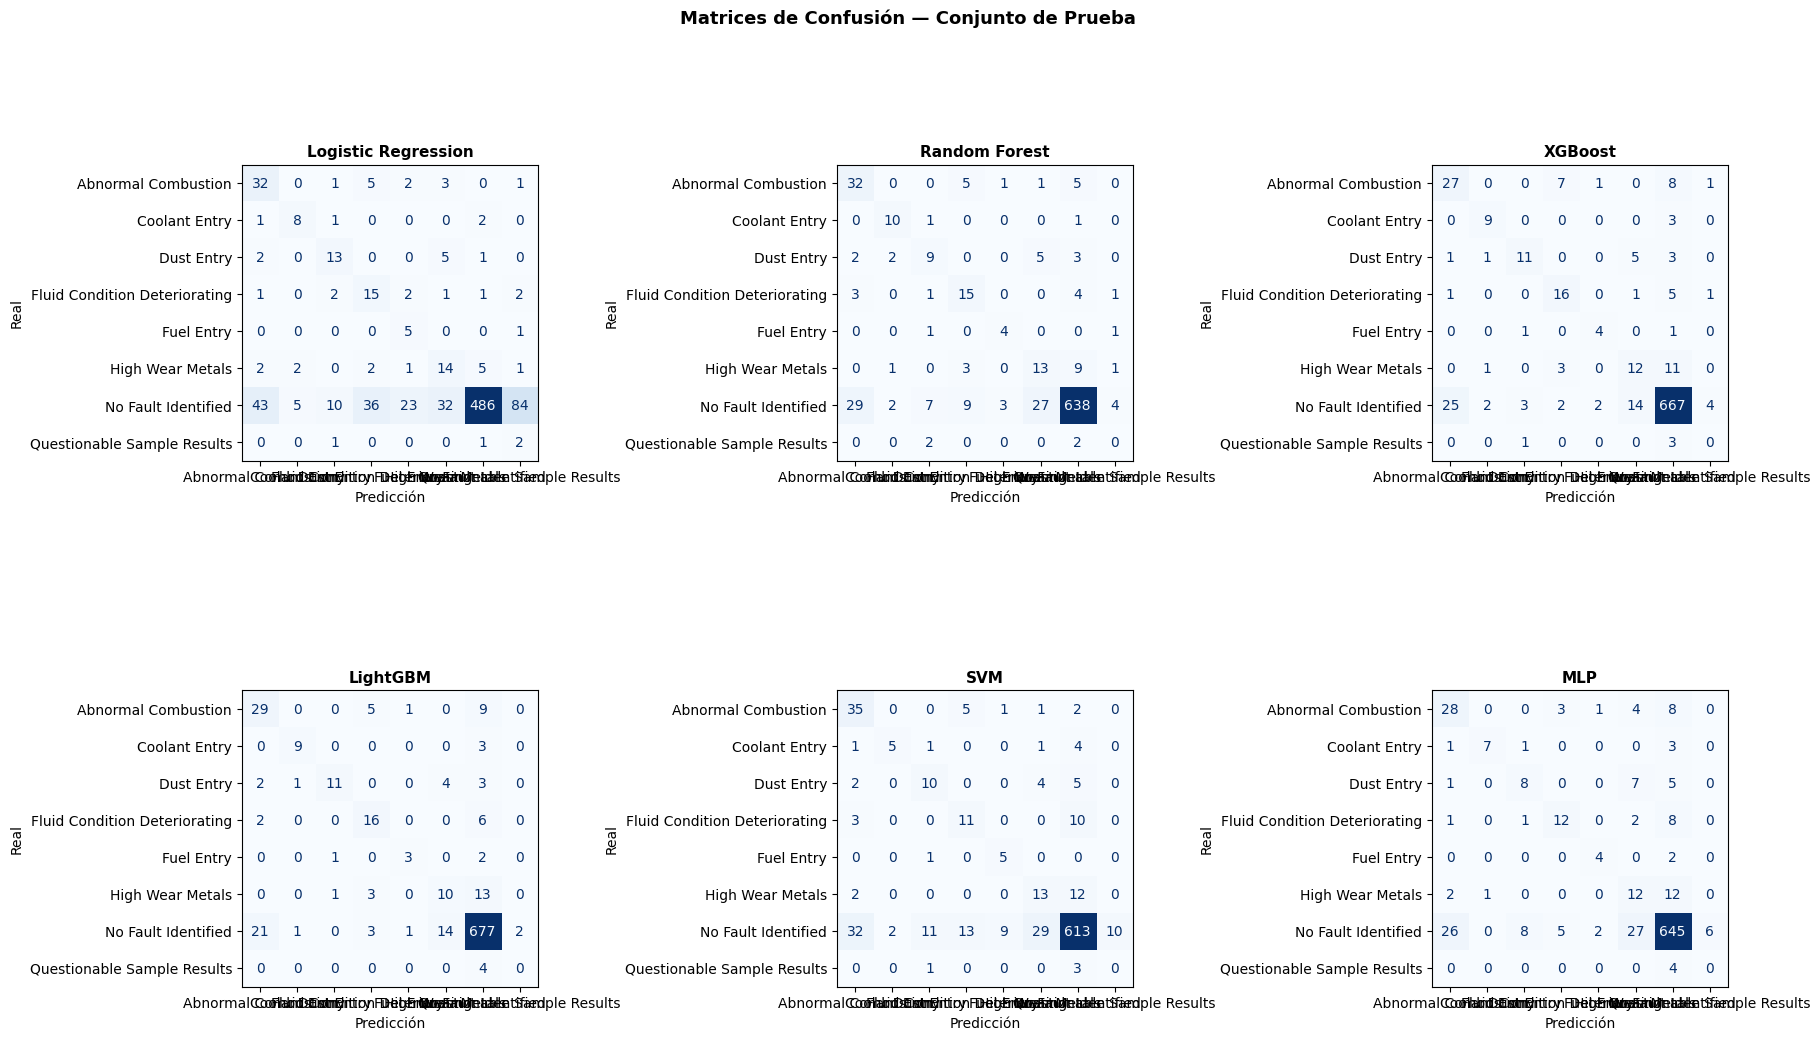

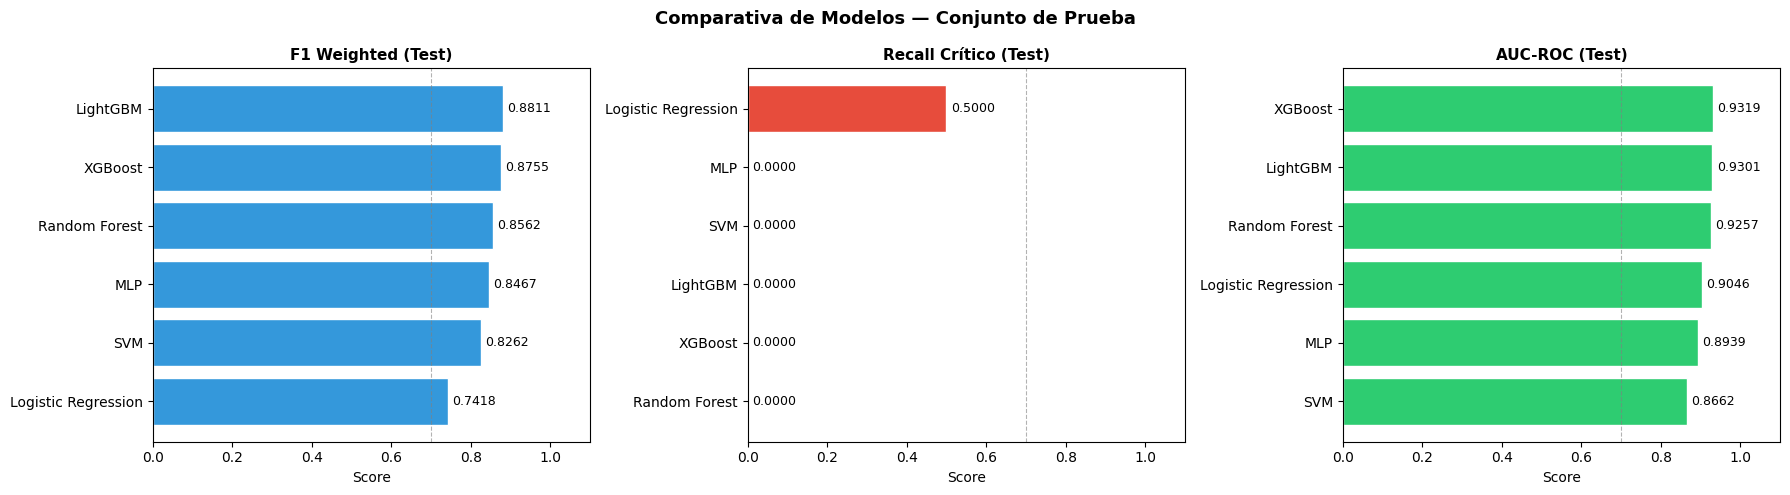

In [42]:
# ==============================================================================
# PIPELINE DE ENTRENAMIENTO — OilSense ML (Con ColumnTransformer)
# Manejo explícito de features numéricas + categóricas SACODE
# ==============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.neural_network   import MLPClassifier
from sklearn.preprocessing    import (LabelEncoder, StandardScaler, 
                                      OrdinalEncoder)
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      ConfusionMatrixDisplay,
                                      f1_score, recall_score,
                                      roc_auc_score)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

os.environ['LOKY_MAX_CPU_COUNT'] = '4'
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. DEFINICIÓN EXPLÍCITA DE COLUMNAS
# ==============================================================================

# Columna índice a eliminar
COLS_DROP = ['Unnamed: 0']

# Features numéricas — pasan por StandardScaler en modelos que lo requieren
COLS_NUMERICAS = [
    'Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)',
    'Magnesio (ppm)', 'Molibdeno (ppm)', 'Agua (%)',
    'Dilución por combustible (%)', 'Hollín JOAP (Abs/cm)',
    'Nitración JOAP (Abs/cm)', 'Oxidación JOAP (Abs/cm)',
    'Silicio (ppm)', 'Sodio (ppm)', 'Sulfatación JOAP (Abs/cm)',
    'Viscosidad @ 100°C (cSt)', 'Aluminio (ppm)', 'Cobre (ppm)',
    'Cromo (ppm)', 'Estaño (ppm)', 'Hierro (ppm)', 'Plomo (ppm)'
]

# Features categóricas SACODE — codificación ordinal respetando severidad
COLS_SACODE = [
    'SACODE_Salud',
    'SACODE_Desgaste',
    'SACODE_Contaminacion',
    'SACODE_General'
]

# Orden de severidad para OrdinalEncoder
ORDEN_SEVERIDAD = [['Normal', 'Advertencia', 'Crítico']] 

label_encoder = LabelEncoder()
label_encoder.fit(y_train_bal)
y_train_enc = label_encoder.transform(y_train_bal)

# ==============================================================================
# 2. PREPARACIÓN DE X e y
# ==============================================================================

X_train_bal_clean = X_train_bal.drop(
    columns=[c for c in COLS_DROP if c in X_train_bal.columns]
)
X_test_clean = X_test.drop(
    columns=[c for c in COLS_DROP if c in X_test.columns]
)

print(f"✅ X_train shape : {X_train_bal_clean.shape}")
print(f"✅ X_test  shape : {X_test_clean.shape}")
print(f"   Numéricas     : {len(COLS_NUMERICAS)} columnas")
print(f"   SACODE        : {len(COLS_SACODE)} columnas\n")

# ==============================================================================
# 3. COLUMN TRANSFORMER — Preprocesamiento diferenciado por tipo
# ==============================================================================
# Estrategia:
#   - Numéricas + escalamiento  → para LR, SVM, MLP
#   - Numéricas sin escalamiento → para RF, XGBoost, LightGBM
#   - SACODE → OrdinalEncoder en ambos casos (Normal=0, Advertencia=1, Crítico=2)

# Preprocesador CON escalamiento (LR, SVM, MLP)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),   COLS_NUMERICAS),
        ('cat', OrdinalEncoder(
                    categories = ORDEN_SEVERIDAD * len(COLS_SACODE),
                    handle_unknown = 'use_encoded_value',
                    unknown_value  = -1
                ), COLS_SACODE)
    ],
    remainder = 'drop'
)

# Preprocesador SIN escalamiento (RF, XGBoost, LightGBM)
preprocessor_passthrough = ColumnTransformer(
    transformers=[
        ('num', 'passthrough',      COLS_NUMERICAS),
        ('cat', OrdinalEncoder(
                    categories = ORDEN_SEVERIDAD * len(COLS_SACODE),
                    handle_unknown = 'use_encoded_value',
                    unknown_value  = -1
                ), COLS_SACODE)
    ],
    remainder = 'drop'
)

# ==============================================================================
# 4. DEFINICIÓN DE MODELOS CON PIPELINES DIFERENCIADOS
# ==============================================================================

modelos = {

    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('clf', LogisticRegression(
            multi_class  = 'multinomial',
            solver       = 'lbfgs',
            C            = 1.0,
            max_iter     = 1000,
            class_weight = 'balanced',
            random_state = 42
        ))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_passthrough),
        ('clf', RandomForestClassifier(
            n_estimators     = 400,
            max_depth        = 20,
            min_samples_leaf = 5,
            class_weight     = 'balanced',
            n_jobs           = -1,
            random_state     = 42
        ))
    ]),

    'XGBoost': Pipeline([
        ('preprocessor', preprocessor_passthrough),
        ('clf', XGBClassifier(
            n_estimators     = 300,
            max_depth        = 5,
            learning_rate    = 0.05,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            eval_metric      = 'mlogloss',
            n_jobs           = -1,
            random_state     = 42
        ))
    ]),

    'LightGBM': Pipeline([
        ('preprocessor', preprocessor_passthrough),
        ('clf', LGBMClassifier(
            n_estimators     = 300,
            max_depth        = 5,
            learning_rate    = 0.05,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            class_weight     = 'balanced',
            n_jobs           = -1,
            random_state     = 42,
            verbose          = -1
        ))
    ]),

    'SVM': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('clf', SVC(
            kernel       = 'rbf',
            C            = 10,
            gamma        = 'scale',
            class_weight = 'balanced',
            probability  = True,
            random_state = 42
        ))
    ]),

    'MLP': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('clf', MLPClassifier(
            hidden_layer_sizes  = (128, 64, 32),
            activation          = 'relu',
            solver              = 'adam',
            learning_rate_init  = 0.001,
            max_iter            = 500,
            early_stopping      = True,
            validation_fraction = 0.1,
            random_state        = 42
        ))
    ])
}

# ==============================================================================
# 5. VALIDACIÓN CRUZADA — 5-Fold Estratificado
# ==============================================================================

print("=" * 65)
print("VALIDACIÓN CRUZADA — 5-Fold Estratificado (Train Balanceado)")
print("=" * 65)

CV           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
METRICAS_CV  = ['f1_weighted', 'recall_weighted', 'accuracy']
resultados_cv = {}

for nombre, pipeline in modelos.items():
    print(f"\n  ▶ Entrenando CV: {nombre}...")
    cv_result = cross_validate(
        estimator          = pipeline,
        X                  = X_train_bal_clean,
        y                  = y_train_enc,
        cv                 = CV,
        scoring            = METRICAS_CV,
        n_jobs             = -1,
        return_train_score = False,
        error_score        = 'raise'
    )
    resultados_cv[nombre] = {
        'F1 Weighted (CV)'    : cv_result['test_f1_weighted'].mean(),
        'F1 Weighted Std'     : cv_result['test_f1_weighted'].std(),
        'Recall Weighted (CV)': cv_result['test_recall_weighted'].mean(),
        'Accuracy (CV)'       : cv_result['test_accuracy'].mean(),
    }
    print(f"    F1 Weighted : {resultados_cv[nombre]['F1 Weighted (CV)']:.4f} "
          f"(±{resultados_cv[nombre]['F1 Weighted Std']:.4f})")
    print(f"    Recall      : {resultados_cv[nombre]['Recall Weighted (CV)']:.4f}")
    print(f"    Accuracy    : {resultados_cv[nombre]['Accuracy (CV)']:.4f}")

df_cv = (pd.DataFrame(resultados_cv).T
           .sort_values('F1 Weighted (CV)', ascending=False))
print("\n=== Resumen Validación Cruzada ===")
print(df_cv.round(4))

# ==============================================================================
# 6. ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE TEST
# ==============================================================================

print("\n" + "=" * 65)
print("EVALUACIÓN SOBRE CONJUNTO DE PRUEBA (Distribución Original)")
print("=" * 65)

resultados_test = {}
modelos_fit     = {}


y_test_enc = label_encoder.transform(y_test)
# Fit label_encoder on all unique labels from both train and test
all_labels = pd.concat([y_train_bal, y_test]).unique()
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

y_train_enc = label_encoder.transform(y_train_bal)
y_test_enc = label_encoder.transform(y_test)

# Find the index of the critical class in the encoded labels
# Since we're working with fault effects, not SACODE, we need to identify
# which class represents critical conditions
# For now, use the first available class as fallback if 'Crítico' doesn't exist
try:
    IDX_CRITICO = np.where(label_encoder.classes_ == 'Crítico')[0][0]
except IndexError:
    # Fallback: use the last class (typically the most severe)
    IDX_CRITICO = len(label_encoder.classes_) - 1

for nombre, pipeline in modelos.items():
    print(f"\n{'─' * 50}")
    print(f"  Modelo: {nombre}")
    print(f"{'─' * 50}")

    pipeline.fit(X_train_bal_clean, y_train_enc)
    modelos_fit[nombre] = pipeline

    y_pred       = pipeline.predict(X_test_clean)
    y_pred_proba = (pipeline.predict_proba(X_test_clean)
                    if hasattr(pipeline[-1], 'predict_proba') else None)

    resultados_test[nombre] = {
        'F1 Weighted (Test)'   : f1_score(y_test_enc, y_pred, average='weighted'),
        'F1 Crítico (Test)'    : f1_score(y_test_enc, y_pred,
                                          labels=[IDX_CRITICO], average=None)[0],
        'Recall Crítico (Test)': recall_score(y_test_enc, y_pred,
                                              labels=[IDX_CRITICO], average=None)[0],
        'AUC-ROC (Test)'       : (roc_auc_score(y_test_enc, y_pred_proba,
                                                 multi_class='ovr', average='weighted')
                                  if y_pred_proba is not None else np.nan),
        'Accuracy (Test)'      : (y_pred == y_test_enc).mean()
    }

    print(classification_report(
        y_test_enc, y_pred,
        target_names=label_encoder.classes_
    ))

df_test = (pd.DataFrame(resultados_test).T
             .sort_values('Recall Crítico (Test)', ascending=False))

print("\n=== Resumen Evaluación Test ===")
print(df_test.round(4))

# ==============================================================================
# 7. MATRICES DE CONFUSIÓN
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes      = axes.flatten()

for i, (nombre, pipeline) in enumerate(modelos_fit.items()):
    y_pred = pipeline.predict(X_test_clean)
    cm     = confusion_matrix(y_test_enc, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(nombre, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ==============================================================================
# 8. COMPARATIVA VISUAL DE MÉTRICAS
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metrica, color) in zip(axes, {
    'F1 Weighted (Test)'   : '#3498db',
    'Recall Crítico (Test)': '#e74c3c',
    'AUC-ROC (Test)'       : '#2ecc71'
}.items()):
    df_plot = df_test[metrica].sort_values(ascending=True)
    bars    = ax.barh(df_plot.index, df_plot.values, color=color, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(metrica, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.axvline(x=0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Comparativa de Modelos — Conjunto de Prueba',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



### Modelo Para Prediccion de Modo de Falla

In [34]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


# Variables predictoras y variable objetivo
X = data_cleaned.drop(columns=['Assigned Condition Rating',
                                'ACR_Homologado',
                                'Assigned Condition Rating',
                                'Fault Effect',
                                'SACODE_Salud',
                                'SACODE_Desgaste',
                                'SACODE_Contaminacion',
                                'SACODE_General','Flota','Rule Based Rating'])

y = data_cleaned['Fault Effect']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       
)

print("=== Distribución antes de SMOTE (Train) ===")
print(y_train.value_counts())

# Aplicación de SMOTE exclusivamente sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n=== Distribución después de SMOTE (Train) ===")
print(pd.Series(y_train_bal).value_counts())
print("\n=== Conjunto de prueba (sin modificar) ===")
print(y_test.value_counts())

=== Distribución antes de SMOTE (Train) ===
Fault Effect
No Fault Identified              2873
Abnormal Combustion               173
High Wear Metals                  108
Fluid Condition Deteriorating      95
Dust Entry                         85
Coolant Entry                      50
Fuel Entry                         24
Questionable Sample Results        18
Name: count, dtype: int64

=== Distribución después de SMOTE (Train) ===
Fault Effect
No Fault Identified              2873
High Wear Metals                 2873
Fluid Condition Deteriorating    2873
Fuel Entry                       2873
Questionable Sample Results      2873
Coolant Entry                    2873
Abnormal Combustion              2873
Dust Entry                       2873
Name: count, dtype: int64

=== Conjunto de prueba (sin modificar) ===
Fault Effect
No Fault Identified              719
Abnormal Combustion               44
High Wear Metals                  27
Fluid Condition Deteriorating     24
Dust Entry        